<a href="https://colab.research.google.com/github/mirian2004/AI-AI-/blob/Day03/Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image

import requests
from io import BytesIO

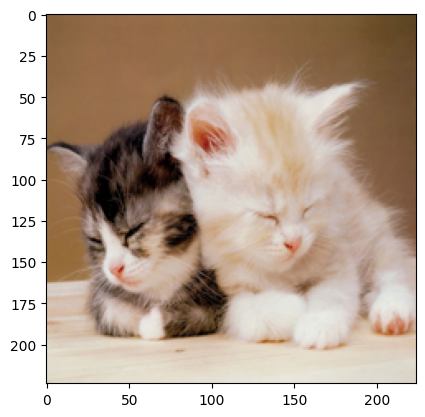

In [ ]:
# 1. 이미지 준비 (고양이 사진)
# 웹에서 고양이 이미지 다운로드
url = "https://i.pinimg.com/originals/50/04/92/500492c75cdf421bbd8ad6429a7a2a39.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

plt.imshow(image.resize((224,224)))

In [ ]:
# 2. 사전 학습된 VGG16 모델 로드
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# 학습 모드가 아닌 평가 모드로 설정 (Dropout 등을 끔)
model.eval()

print("VGG16 모델 로드 완료!")
print(model.features) # 모델의 층 구조 출력

# VGG16 모델에 맞는 형태로 전처리 (크기 조절, 텐서 변환, 정규화)
preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.299, 0.224, 0.225]),
])
input_tensor = preprocess(image).unsqueeze(0) # 배치 차원 추가: [1,3,224,224]

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:09<00:00, 57.3MB/s]


VGG16 모델 로드 완료!
Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256

In [ ]:
# 3. 특징 맵(Feature Map) 추출 함수
feature_maps = []

# 모델의 특정 레이어를 통과할 때마다 출력을 낚아채는(Hook) 함수
def hook_fn(module, input, output):
  feature_maps.append(output)

# 보고 싶은 레이어 지정 (VGG16의 구조 참고)
# features[0] : 첫번째 Conv 레이어 (아주 기초적인 특징)
# features[10] : 중간 단계 Conv 레이어
# features[20] : 마지막 단계 Conv 레이어 (고차원적 특징)
target_layers = [model.features[0], model.features[10], model.features[20]]

# 각 레이어에 Hook 등록
for layer in target_layers:
  layer.register_forward_hook(hook_fn)

with torch.no_grad():
  model(input_tensor)


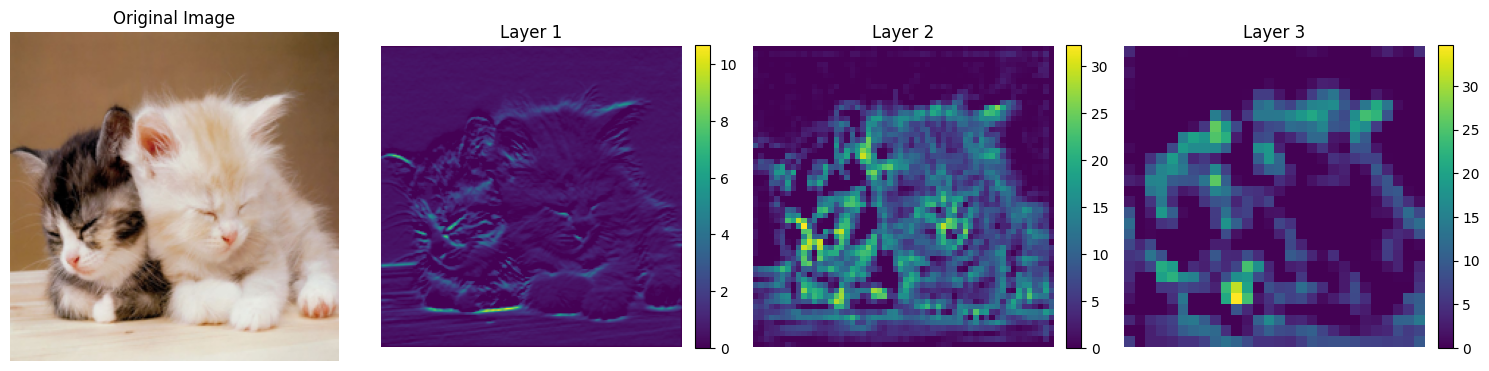

Layer 1: 색깔이 검은색인 부분에서 높은 활성화
Layer 10: 고양이와 배경의 오른쪽 경계 부분에서 높은 활설화
Layer 20: 고양이의 두 귀에 대해서 높은 활성화


In [ ]:
# 4. 추출한 특징 시각화
# 시각화 설정
layer_names = ["Layer 1", "Layer 2", "Layer 3"]

plt.figure(figsize=(15, 8))

# 원본 이미지 출력 (비교용)
plt.subplot(1,4,1)
plt.imshow(image.resize((224,224)))
plt.title("Original Image")
plt.axis("off")

# 각 레이어별 특징 맵 3개씩만 뽑아서 출력
for i, fmap in enumerate(feature_maps):

  # fmap 형태: [1, 채널수, 높이, 너비] -> [채널수, 높이, 너비]
  fmap = fmap.squeeze(0)

  # 가장 활성화된 채널 선택
  mean_activations = torch.mean(fmap, dim=(1,2))
  _, top_indices = torch.topk(mean_activations, 1)

  ax = plt.subplot(1,4,i+2)

  # imshow 반환값 지정
  im = ax.imshow(
      fmap[top_indices][0].detach().cpu().numpy(),
      cmap = 'viridis'
  )

  ax.set_title(f"{layer_names[i]}")
  ax.axis('off')

  # colorbar 추가(각 subplot별)
  plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Layer 1: 색깔이 검은색인 부분에서 높은 활성화")
print("Layer 10: 고양이와 배경의 오른쪽 경계 부분에서 높은 활설화")
print("Layer 20: 고양이의 두 귀에 대해서 높은 활성화")

각 레이어의 출력을 살펴볼 수 있다.
레이어가 깊어질 수록 점차 단순 -> 고차원적 특징을 학습한다.